# ============================================================
# PERSON 2 — Classical ML Models
# NLP Customer Complaint Router — SAP ABAP Capstone Project
# ============================================================
# Run AFTER Person 1 has generated train.csv and test.csv
# ============================================================


In [44]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb


In [46]:
# ── STEP 1: Load Data ──────────────────────────────────────────────────────────

print("📦 Loading data...")
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

X_train = train_df['cleaned_complaint']
y_train = train_df['category']
X_test  = test_df['cleaned_complaint']
y_test  = test_df['category']

# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"✅ Train: {len(X_train)} | Test: {len(X_test)}")
print(f"   Classes: {list(le.classes_)}")

📦 Loading data...
✅ Train: 800 | Test: 200
   Classes: ['Account Issue', 'Billing Issue', 'Delivery Problem', 'Product Defect', 'Refund Request']


In [47]:
# ── STEP 2: TF-IDF Vectorizer ──────────────────────────────────────────────────

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words='english',
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"\n✅ TF-IDF shape: {X_train_tfidf.shape}")



✅ TF-IDF shape: (800, 307)


In [48]:
# ── STEP 3: Train Models ───────────────────────────────────────────────────────

results = {}

# Model 1: Logistic Regression (Baseline)
print("\n🔄 Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_preds),
    'f1':       f1_score(y_test, lr_preds, average='weighted'),
    'preds':    lr_preds
}
print(f"   Accuracy: {results['Logistic Regression']['accuracy']:.4f}")



🔄 Training Logistic Regression...
   Accuracy: 1.0000


In [49]:
# Model 2: Random Forest
print("\n🔄 Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_preds = rf.predict(X_test_tfidf)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_preds),
    'f1':       f1_score(y_test, rf_preds, average='weighted'),
    'preds':    rf_preds
}
print(f"   Accuracy: {results['Random Forest']['accuracy']:.4f}")



🔄 Training Random Forest...
   Accuracy: 1.0000


In [50]:
# Model 3: XGBoost
print("\n🔄 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train_tfidf, y_train_enc)
xgb_preds_enc = xgb_model.predict(X_test_tfidf)
xgb_preds     = le.inverse_transform(xgb_preds_enc)
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_preds),
    'f1':       f1_score(y_test, xgb_preds, average='weighted'),
    'preds':    xgb_preds
}
print(f"   Accuracy: {results['XGBoost']['accuracy']:.4f}")


🔄 Training XGBoost...
   Accuracy: 1.0000


In [51]:
# ── STEP 4: Model Comparison Visualization ─────────────────────────────────────

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Classical ML Models — Comparison Dashboard', fontsize=16, fontweight='bold')

model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1'] for m in model_names]
colors      = ['#3498DB', '#E74C3C', '#2ECC71']


In [52]:
# Plot 1: Accuracy Comparison
ax = axes[0, 0]
bars = ax.bar(model_names, accuracies, color=colors)
ax.set_title('Accuracy Comparison', fontweight='bold')
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontweight='bold')

In [53]:
# Plot 2: F1 Score Comparison
ax = axes[0, 1]
bars = ax.bar(model_names, f1_scores, color=colors)
ax.set_title('F1 Score (Weighted)', fontweight='bold')
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('F1 Score')
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontweight='bold')

In [54]:
# Plot 3: Confusion Matrix — Best Model (XGBoost)
ax = axes[0, 2]
best_preds = results['XGBoost']['preds']
cm = confusion_matrix(y_test, best_preds, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

In [55]:
# Plot 4: Classification Report — XGBoost
ax = axes[1, 0]
report = classification_report(y_test, best_preds, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, color=['#3498DB','#E74C3C','#2ECC71'])
ax.set_title('Precision / Recall / F1 by Class', fontweight='bold')
ax.set_ylim(0.7, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='lower right')


In [56]:
# Plot 5: Top TF-IDF Features
ax = axes[1, 1]
feature_names = tfidf.get_feature_names_out()
lr_coef = np.abs(lr.coef_).mean(axis=0)
top_idx = lr_coef.argsort()[-15:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_scores   = [lr_coef[i] for i in top_idx]
ax.barh(top_features[::-1], top_scores[::-1], color='#9B59B6')
ax.set_title('Top 15 TF-IDF Features (LR)', fontweight='bold')
ax.set_xlabel('Avg Coefficient Magnitude')


Text(0.5, 109.5833333333333, 'Avg Coefficient Magnitude')

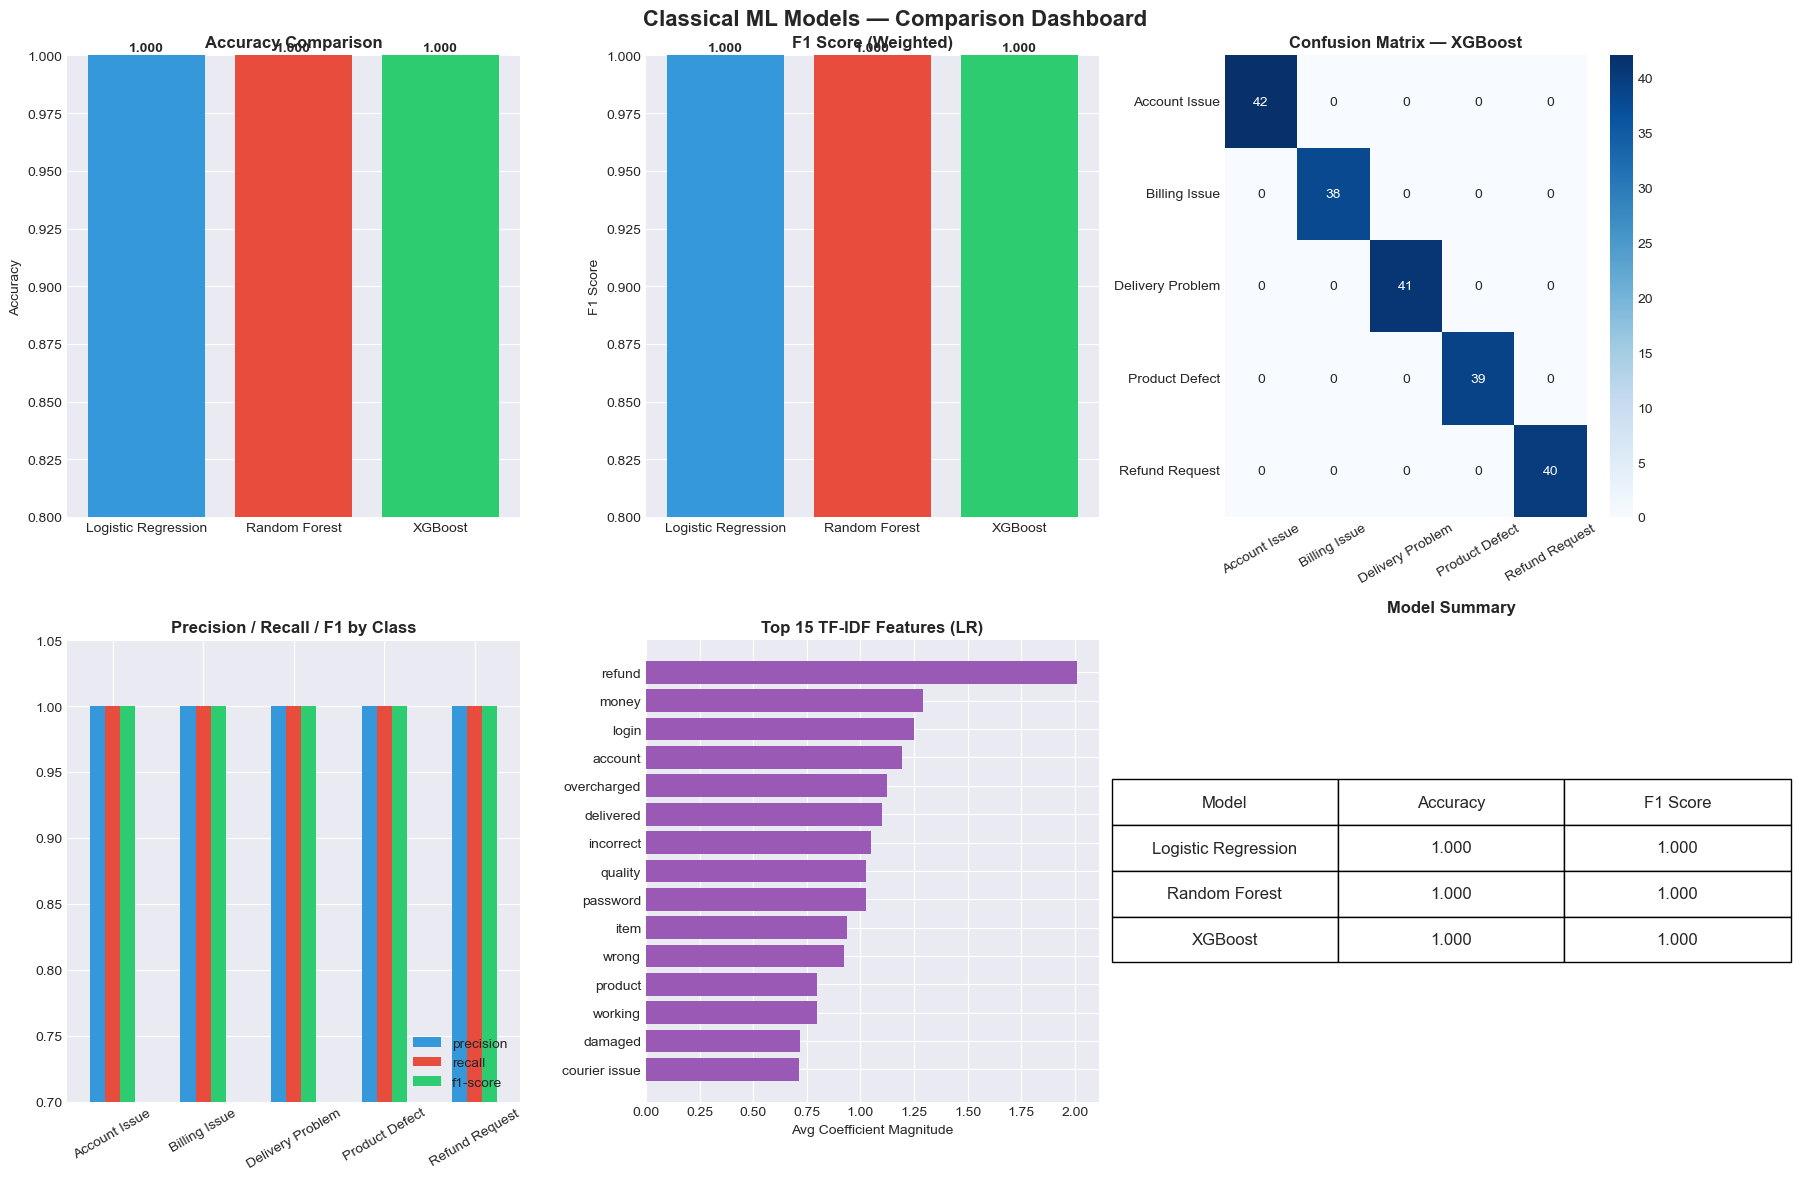


✅ Model comparison saved as ml_comparison.png


In [57]:
# Plot 6: Summary Table
ax = axes[1, 2]
ax.axis('off')
table_data = [[m, f'{results[m]["accuracy"]:.3f}', f'{results[m]["f1"]:.3f}']
              for m in model_names]
table = ax.table(
    cellText=table_data,
    colLabels=['Model', 'Accuracy', 'F1 Score'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.5)
ax.set_title('Model Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model comparison saved as ml_comparison.png")

In [60]:
# ── STEP 5: Save Best Model ────────────────────────────────────────────────────

# Save XGBoost + TF-IDF + LabelEncoder
joblib.dump(xgb_model, 'model_xgb.pkl')
joblib.dump(tfidf,     'tfidf_vectorizer.pkl')
joblib.dump(le,        'label_encoder.pkl')

# Also save Logistic Regression as backup (lighter, faster)
joblib.dump(lr, 'model_lr.pkl')

print("\n✅ Models saved:")
print("   model_xgb.pkl")
print("   model_lr.pkl")
print("   tfidf_vectorizer.pkl")
print("   label_encoder.pkl")



✅ Models saved:
   model_xgb.pkl
   model_lr.pkl
   tfidf_vectorizer.pkl
   label_encoder.pkl


In [61]:
# ── STEP 6: Quick Inference Test ──────────────────────────────────────────────

routing_map = {
    'Billing Issue':    'Finance Team',
    'Delivery Problem': 'Logistics Team',
    'Product Defect':   'Quality Team',
    'Refund Request':   'Finance Team',
    'Account Issue':    'IT Support Team',
}

priority_map = {
    'Billing Issue':    'HIGH',
    'Delivery Problem': 'MEDIUM',
    'Product Defect':   'HIGH',
    'Refund Request':   'MEDIUM',
    'Account Issue':    'LOW',
}

def predict_complaint(text):
    cleaned = text.lower()
    vec     = tfidf.transform([cleaned])
    pred    = le.inverse_transform(xgb_model.predict(vec))[0]
    proba   = xgb_model.predict_proba(vec).max()
    return {
        'category':   pred,
        'route_to':   routing_map[pred],
        'priority':   priority_map[pred],
        'confidence': round(float(proba), 4)
    }

test_complaints = [
    "I was charged twice for the same invoice",
    "My package has not arrived yet it has been 2 weeks",
    "The product I received is completely broken",
]

print("\n🧪 Quick inference test:")
for c in test_complaints:
    result = predict_complaint(c)
    print(f"\n  Input:      '{c}'")
    print(f"  Category:   {result['category']}")
    print(f"  Route to:   {result['route_to']}")
    print(f"  Priority:   {result['priority']}")
    print(f"  Confidence: {result['confidence']:.1%}")

print("\n🎯 Person 2 task complete! Share .pkl files with Person 3.")



🧪 Quick inference test:

  Input:      'I was charged twice for the same invoice'
  Category:   Billing Issue
  Route to:   Finance Team
  Priority:   HIGH
  Confidence: 97.9%

  Input:      'My package has not arrived yet it has been 2 weeks'
  Category:   Billing Issue
  Route to:   Finance Team
  Priority:   HIGH
  Confidence: 36.5%

  Input:      'The product I received is completely broken'
  Category:   Product Defect
  Route to:   Quality Team
  Priority:   HIGH
  Confidence: 99.0%

🎯 Person 2 task complete! Share .pkl files with Person 3.
